# WIKI-IMDB Transfer Learning Weights to create HDF File

In [51]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = False ## Not trainable weights
base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [53]:
wiki_model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense_5 (Dense)             (None, 4000)              100356000 
                                                                 
 dropout_2 (Dropout)         multiple                  0         
                                                                 
 dense_6 (Dense)             (None, 200)               800200    
                                                                 
 dense_7 (Dense)             (None, 18)                3618      
                                                                 
Total params: 115,874,506
Trainable params: 101,159,81

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

wiki_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)


es = EarlyStopping(monitor='val_accuracy', mode='max', patience=10,  restore_best_weights=True)

history  = wiki_model.fit(train_generator,
                    validation_data = valid_generator,
                    steps_per_epoch = train_generator.n//train_generator.batch_size,
                    validation_steps = valid_generator.n//valid_generator.batch_size,
                    epochs=20, callbacks=[es])


Epoch 1/20
457/457 [==============================] - 225s 490ms/step - loss: 2.2997 - accuracy: 0.3575 - val_loss: 1.6995 - val_accuracy: 0.4118
Epoch 2/20
457/457 [==============================] - 221s 484ms/step - loss: 1.8279 - accuracy: 0.3925 - val_loss: 1.5910 - val_accuracy: 0.4212
Epoch 3/20
457/457 [==============================] - 221s 484ms/step - loss: 1.6551 - accuracy: 0.4365 - val_loss: 1.4238 - val_accuracy: 0.5041
Epoch 4/20
457/457 [==============================] - 221s 484ms/step - loss: 1.5461 - accuracy: 0.4710 - val_loss: 1.3935 - val_accuracy: 0.5059
Epoch 5/20
457/457 [==============================] - 221s 484ms/step - loss: 1.4736 - accuracy: 0.4877 - val_loss: 1.3785 - val_accuracy: 0.5049
Epoch 6/20
457/457 [==============================] - 221s 483ms/step - loss: 1.4417 - accuracy: 0.4994 - val_loss: 1.3535 - val_accuracy: 0.5251
Epoch 7/20
457/457 [==============================] - 221s 484ms/step - loss: 1.3967 - accuracy: 0.5093 - val_loss: 1.3308 -

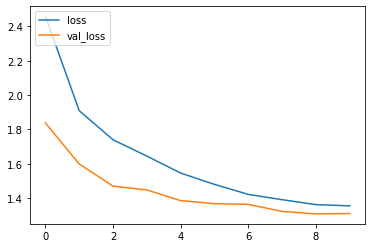

In [ ]:
import matplotlib.pyplot as plt
# training loss and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'], loc='upper left')
plt.show()

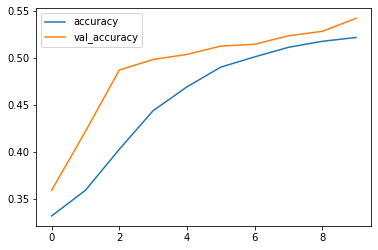

In [ ]:
# training accuracy and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['accuracy', 'val_accuracy'], loc='upper left')
plt.show()

In [ ]:
# save wiki_model
wiki_model.save('./wiki_model.h5')

In [ ]:
# saving model in drive
!cp /content/wiki_model.h5 /content/drive/MyDrive